In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.shape

(167, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# DATA QUALITY CHECK

In [7]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["country"].nunique()

167

# EDA

## Distribution

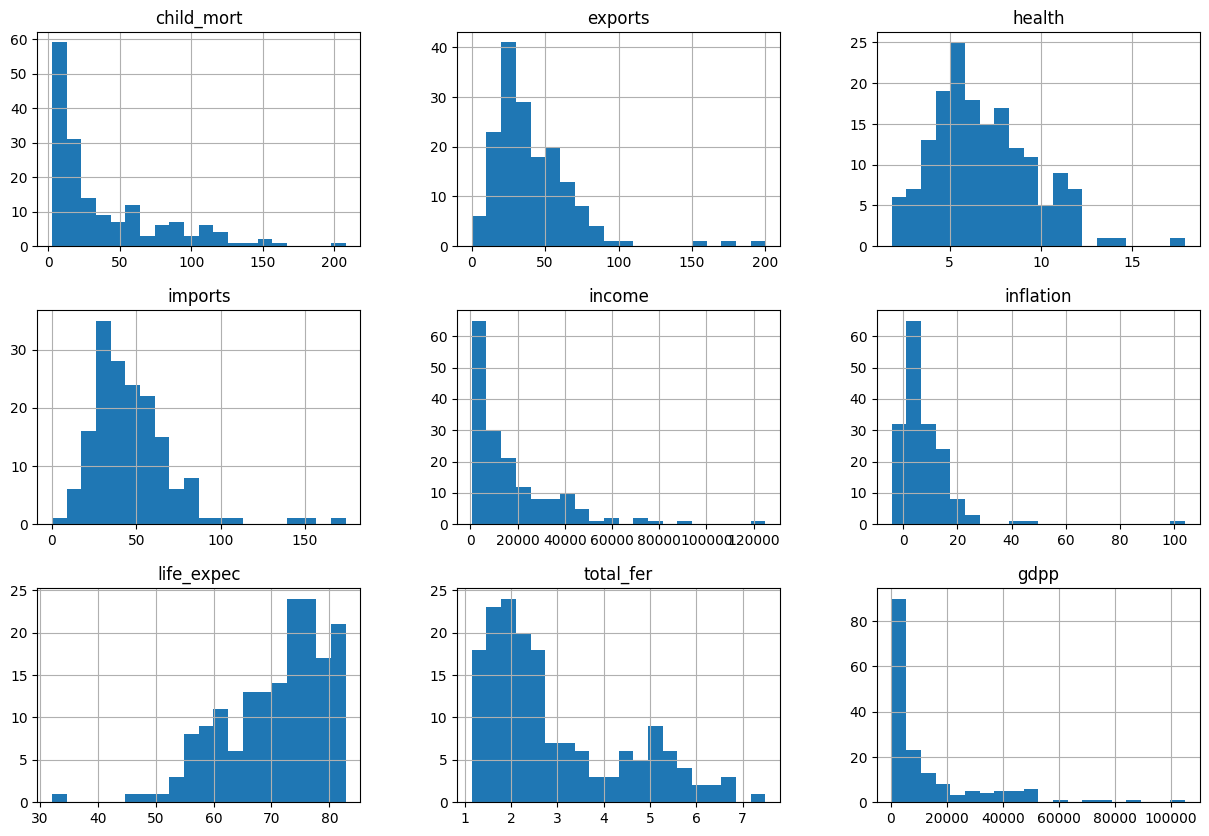

In [10]:
df.drop("country",axis=1).hist(figsize=(15,10),bins=20)
plt.show()

## Outliers

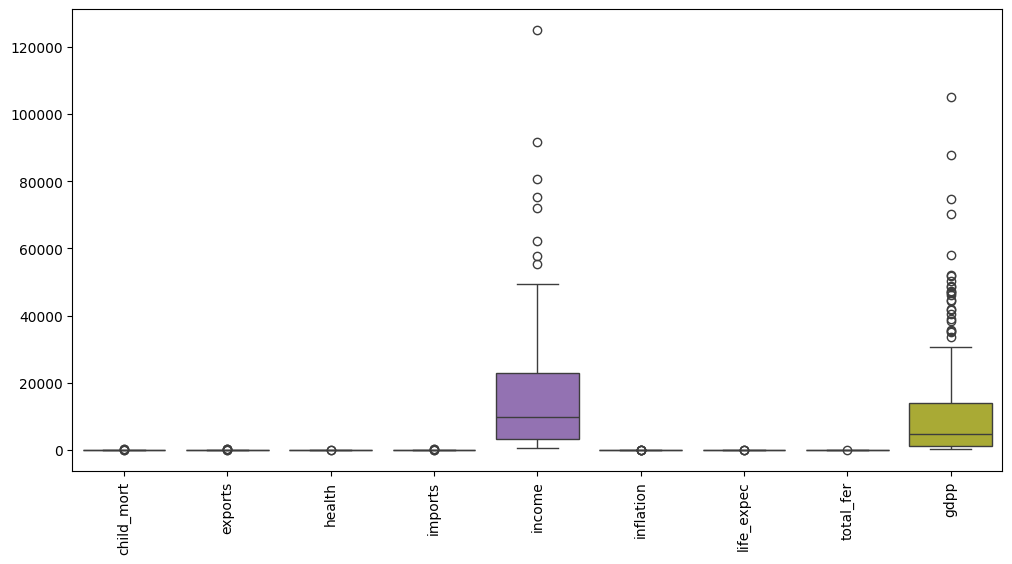

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("country",axis=1))
plt.xticks(rotation=90)
plt.show()

## Correlation

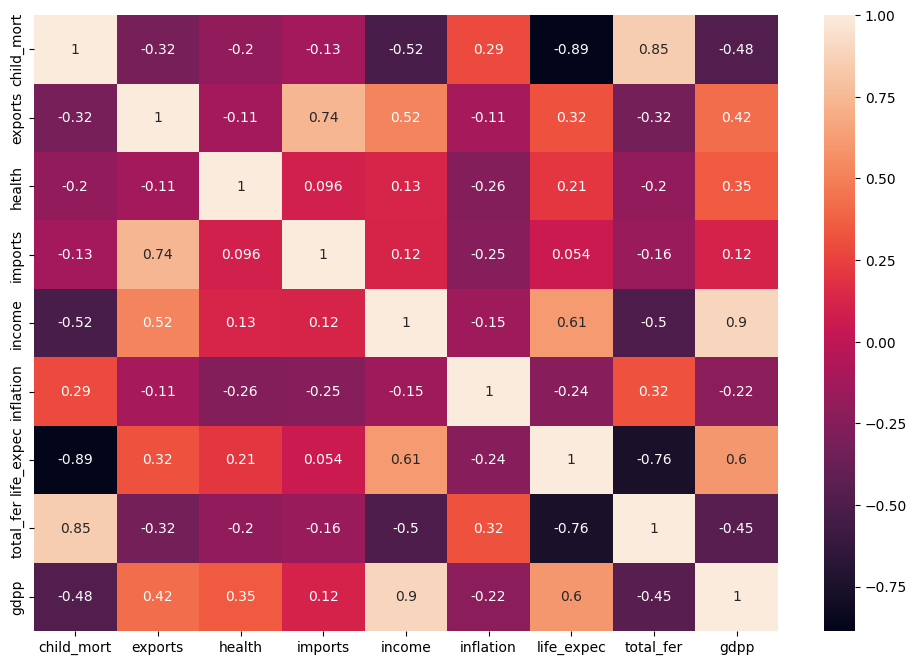

In [12]:
plt.figure(
    figsize=(12,8)
)
sns.heatmap(
    df.drop(
        "country",
        axis=1
    ).corr(),
    annot=True
)
plt.show()

# Data processing

In [13]:
X = df.drop("country",axis=1)

## Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Kmeans Clustering


## Elbow Method

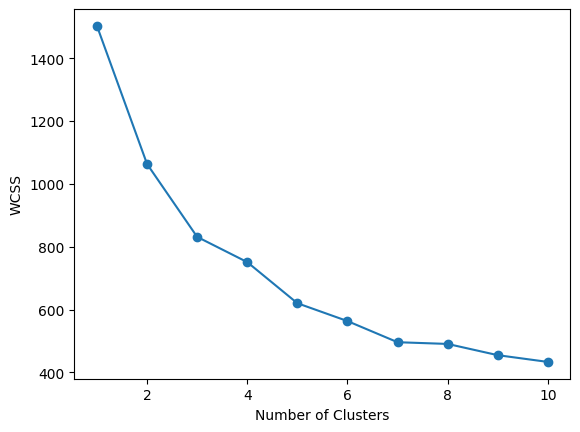

In [15]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans = KMeans( n_clusters=3,random_state=42)
kmeans_label = kmeans.fit_predict(X_scaled)
df["KMeans_cluster"] = kmeans_label
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [17]:
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled,kmeans_label))

0.285600988953231


## PCA Visualization

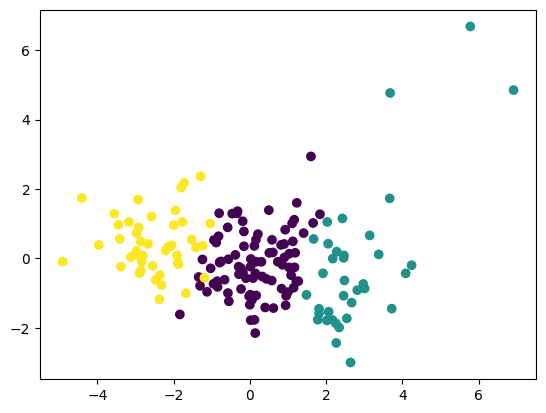

In [18]:
from sklearn.decomposition import PCA
pca = PCA(
    n_components=2
)
pca_data = pca.fit_transform(
    X_scaled
)
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans_label
)
plt.show()

# DBSCAN Clustering

In [19]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2,min_samples=5)
db_label = dbscan.fit_predict(X_scaled)
df["DBSCAN_cluster"]=db_label
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cluster,DBSCAN_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


In [20]:
df["DBSCAN_cluster"].value_counts()

DBSCAN_cluster
 0    152
-1     15
Name: count, dtype: int64

# Classification data

In [21]:
y=df["KMeans_cluster"]

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

# Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Hyperparameter Tuning

In [25]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid_rf.fit(X_train,y_train)
print(grid_rf.best_params_)

{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}


In [26]:
best_rf = grid_rf.best_estimator_
rf_tuned_pred = best_rf.predict(X_test)
print(accuracy_score(y_test,rf_tuned_pred))
print(classification_report(y_test,rf_tuned_pred))

0.9705882352941176
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      1.00      1.00         8
           2       1.00      0.83      0.91         6

    accuracy                           0.97        34
   macro avg       0.98      0.94      0.96        34
weighted avg       0.97      0.97      0.97        34



# XGBOOST

In [27]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

In [28]:
print(accuracy_score(y_test,xgb_pred))
print(classification_report(y_test,xgb_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Hyperparameter Tuning

In [29]:
from sklearn.model_selection import GridSearchCV
xgb_params = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2]
}
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    xgb_params,
    cv=5,
    scoring="accuracy"
)
grid_xgb.fit(X_train,y_train)
print(grid_xgb.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [30]:
best_xgb = grid_xgb.best_estimator_
xgb_tuned_pred = best_xgb.predict(
    X_test
)
print(
    accuracy_score(
        y_test,
        xgb_tuned_pred
    )
)
print(
    classification_report(
        y_test,
        xgb_tuned_pred
    )
)

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# Model comparison

In [31]:
result=pd.DataFrame(
{"Model":["RF","Tuned RF","XGB","Tuned XGB"],
"Accuracy":[
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,rf_tuned_pred),
accuracy_score(y_test,xgb_pred),
accuracy_score(y_test,xgb_tuned_pred)
]
}
)
result

,Model,Accuracy
0,RF,1.000000
1,Tuned RF,0.970588
2,XGB,1.000000
3,Tuned XGB,1.000000


##  best model

In [32]:
result.sort_values("Accuracy",ascending=False)

,Model,Accuracy
0,RF,1.000000
2,XGB,1.000000
3,Tuned XGB,1.000000
1,Tuned RF,0.970588


In [33]:
importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf.feature_importances_
    }
)


importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,child_mort,0.293845
8,gdpp,0.210125
4,income,0.177148
7,total_fer,0.142312
6,life_expec,0.122588
2,health,0.019921
1,exports,0.014917
5,inflation,0.011745
3,imports,0.007400


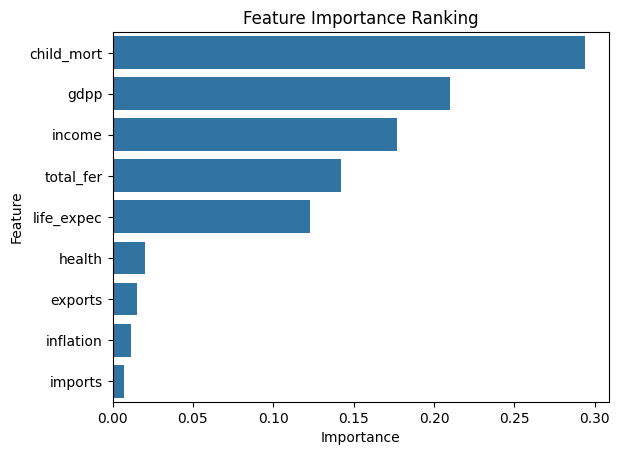

In [34]:
importance_sorted = importance.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    data=importance_sorted,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Ranking")
plt.show()

# Conclusion
In this project, a Country Development Intelligence System was developed using machine learning and clustering techniques to analyze socio-economic indicators of different countries.

Key outcomes:

- Exploratory Data Analysis identified important relationships among factors such as GDP per capita, income, child mortality, fertility rate, and life expectancy.

- K-Means clustering successfully segmented countries into different development groups based on their economic and health indicators.

- DBSCAN clustering helped identify unique country patterns and possible outlier economies.

- Random Forest and XGBoost classification models were trained to predict country development categories generated from clustering results.

- Hyperparameter tuning improved model optimization and helped select the best-performing model.

- Feature importance analysis showed that child mortality, GDP per capita, income, fertility rate, and life expectancy are the most influential factors affecting country development status.

Overall, the system provides a data-driven approach for understanding global development patterns and generating actionable insights for socio-economic decision making.